# PCA through Singular Value Decomposition

In [1]:
import numpy as np
# Defined 3 points in 2D-space:
X=np.array([[2, 1, 0],[4, 3, 0]])
# Calculate the covariance matrix:
R=np.cov(X.T)
# Calculate the SVD decomposition and new basis vectors:
[U,D,V]=np.linalg.svd(R)  # call SVD decomposition
u1=U[:,0] # new basis vectors
u2=U[:,1]
print("u1=",u1)
print("u2=",u2)
# Calculate the coordinates in new orthonormal basis:
X_proj=np.dot(U.T, X.T).T # On transpose X pour avoir (3,2), le résultat est (3,2), puis on re-transpose

# Calculate the approximation of the original from new basis
X_approx = np.dot(X_proj[:, 0:1], U[:, 0:1].T)
print(X_approx)
#print(Xi1[:,None]) # add second dimention to array and test it


# Check that you got the original
X_reconstructed= np.dot(X_proj, U.T)
print(X_reconstructed)

u1= [-0.70710678 -0.70710678  0.        ]
u2= [0. 0. 1.]
[[1.5 1.5 0. ]
 [3.5 3.5 0. ]]
[[2. 1. 0.]
 [4. 3. 0.]]


# PCA on Iris data

In [2]:
# Load Iris dataset as in the last PC lab:
from sklearn.datasets import load_iris
iris=load_iris()
iris.feature_names
print(iris.feature_names)
print(iris.data[0:5,:])
print(iris.target[:])

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]]
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


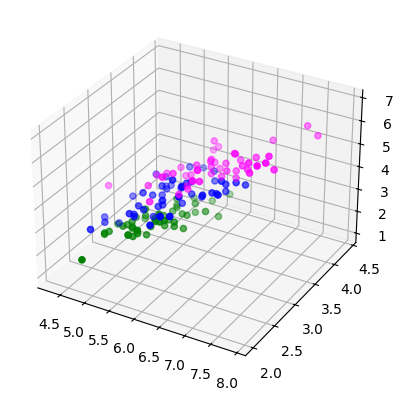

In [ ]:
# We have 4 dimensions of data, plot the first three colums in 3D
X=iris.data
y=iris.target
import matplotlib.pyplot as plt
axes1=plt.axes(projection='3d')
axes1.scatter3D(X[y==0,0],X[y==0,1],X[y==0,2],color='green')
axes1.scatter3D(X[y==1,0],X[y==1,1],X[y==1,2],color='blue')
axes1.scatter3D(X[y==2,0],X[y==2,1],X[y==2,2],color='magenta')
plt.show()



[[ 1.00671141 -0.11835884  0.87760447  0.82343066]
 [-0.11835884  1.00671141 -0.43131554 -0.36858315]
 [ 0.87760447 -0.43131554  1.00671141  0.96932762]
 [ 0.82343066 -0.36858315  0.96932762  1.00671141]]


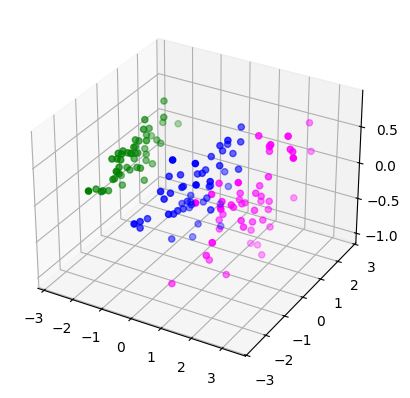

In [ ]:
# Pre-processing is an important step, you can try either StandardScaler (zero mean, unit variance of features)
# or MinMaxScaler (to interval from 0 to 1)
from sklearn import preprocessing
from sklearn.preprocessing import StandardScaler
from sklearn import decomposition
Xscaler = StandardScaler()
Xpp=Xscaler.fit_transform(X)

# define PCA object (three components), fit and transform the data
pca = decomposition.PCA(n_components=3)
pca.fit(Xpp)
Xpca = pca.transform(Xpp)
print(pca.get_covariance())
# you can plot the transformed feature space in 3D:
axes2=plt.axes(projection='3d')
axes2.scatter3D(Xpca[y==0,0],Xpca[y==0,1],Xpca[y==0,2],color='green')
axes2.scatter3D(Xpca[y==1,0],Xpca[y==1,1],Xpca[y==1,2],color='blue')
axes2.scatter3D(Xpca[y==2,0],Xpca[y==2,1],Xpca[y==2,2],color='magenta')
plt.show()


In [ ]:
# Compute pca.explained_variance_ and pca.explained_variance_ratio_values
pca.explained_variance_


array([2.93808505, 0.9201649 , 0.14774182])

In [ ]:
pca.explained_variance_ratio_

array([0.72962445, 0.22850762, 0.03668922])

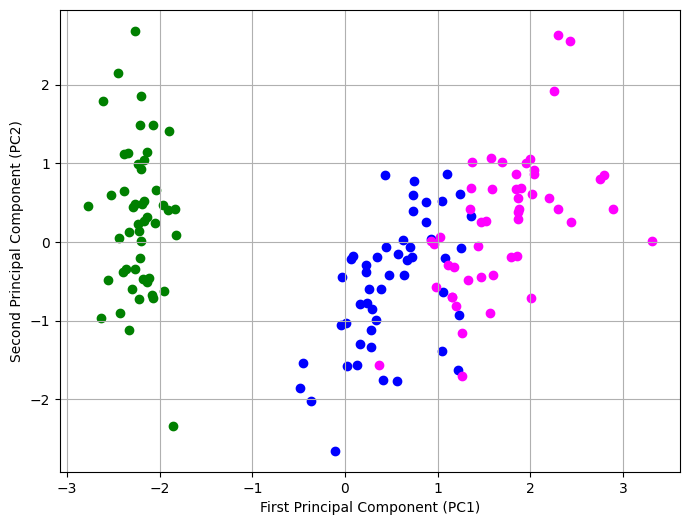

In [ ]:
# Plot the principal components in 2D, mark different targets in color

# Plot the principal components in 2D, mark different targets in color
plt.figure(figsize=(8, 6))


plt.scatter(Xpca[y==0, 0], Xpca[y==0, 1], color='green')
plt.scatter(Xpca[y==1, 0], Xpca[y==1, 1], color='blue')
plt.scatter(Xpca[y==2, 0], Xpca[y==2, 1], color='magenta')

plt.xlabel('First Principal Component (PC1)')
plt.ylabel('Second Principal Component (PC2)')
plt.grid(True)
plt.show()

# KNN classifier

[[10  0  0]
 [ 0  9  0]
 [ 0  0 11]]


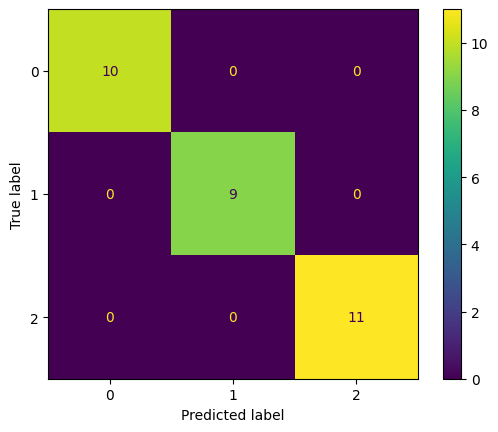

In [ ]:
# Import train_test_split as in last PC lab, split X (original) into train and test, train KNN classifier on full 4-dimensional X
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

knn1=KNeighborsClassifier(n_neighbors = 3)
knn1.fit(X_train, y_train)
Ypred=knn1.predict(X_test)

# Import and show confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, Ypred)
print(cm)

ConfusionMatrixDisplay.from_predictions(y_test, Ypred)

[[10  0  0]
 [ 0  7  2]
 [ 0  0 11]]


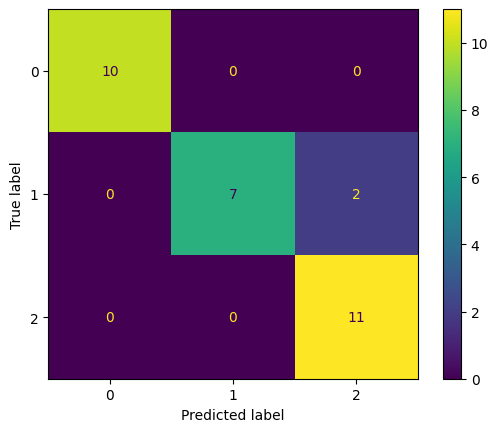

In [ ]:
# Now do the same (data set split, KNN, confusion matrix), but for PCA-transformed data (1st two principal components, i.e., first two columns).
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

X_pca_2d = Xpca[:, 0:2]
X_train_pca, X_test_pca, y_train_pca, y_test_pca = train_test_split(X_pca_2d, y, test_size=0.2, random_state=42)

knn_pca=KNeighborsClassifier(n_neighbors = 3)
knn_pca.fit(X_train_pca, y_train_pca)
Ypred_pca=knn_pca.predict(X_test_pca)

# Import and show confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_pca = confusion_matrix(y_test_pca, Ypred_pca)
print(cm_pca)

ConfusionMatrixDisplay.from_predictions(y_test_pca, Ypred_pca)

[[10  0  0]
 [ 0  7  2]
 [ 0  3  8]]


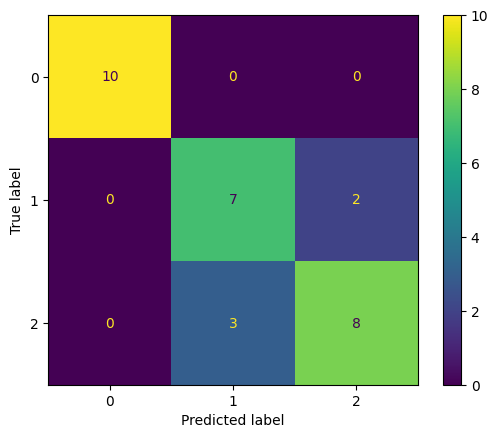

In [ ]:
# Now do the same, but use only 2-dimensional data of original X (first two columns)
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier

# On utilise uniquement les deux premières colonnes de X (Original)
X_2d = X[:, 0:2]
X_train_2d, X_test_2d, y_train_2d, y_test_2d = train_test_split(X_2d, y, test_size=0.2, random_state=42)

knn_2d=KNeighborsClassifier(n_neighbors = 3)
knn_2d.fit(X_train_2d, y_train_2d)
Ypred_2d=knn_2d.predict(X_test_2d)

# Import and show confusion matrix
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

cm_2d = confusion_matrix(y_test_2d, Ypred_2d)
print(cm_2d)

ConfusionMatrixDisplay.from_predictions(y_test_2d, Ypred_2d)